<a href="https://colab.research.google.com/github/JakeFRCSE/refusal-direction-reproduction/blob/main/notebooks/refusal_direction_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Refusal Direction in LLMs

Goal
Reproduce the experiment of Section 3 of
["Refusal in Language Models Is Mediated by a Single Direction"](https://arxiv.org/pdf/2406.11717)

Main steps
1. Extract residual directions
2. Compute candidate directions
3. Select optimal direction following the paper
4. Run intervention experiments

# 0. Loading Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
from pathlib import Path
import json
from itertools import combinations

In [3]:
DATASET_DIR = Path("/content/drive/MyDrive/research/research-cycle1/throw-away-projects/refusal/dataset/processed")

SPLIT_SIZES = {
    "train": 128,
    "val": 32,
    "test": 100,
}

CATEGORIES = ["harmful", "harmless"]


def load_dataset(file_name: str, dir_path: Path = DATASET_DIR):
    with open(dir_path / file_name, "r", encoding="utf-8") as f:
        return json.load(f)


def load_split(category: str, split: str, dir_path: Path = DATASET_DIR):
    file_name = f"{category}_{split}.json"
    data = load_dataset(file_name, dir_path)
    return data[:SPLIT_SIZES[split]]


datasets = {
    category: {
        split: load_split(category, split)
        for split in SPLIT_SIZES
    }
    for category in CATEGORIES
}

harmful_train = datasets["harmful"]["train"]
harmful_val = datasets["harmful"]["val"]
harmful_test = datasets["harmful"]["test"]

harmless_train = datasets["harmless"]["train"]
harmless_val = datasets["harmless"]["val"]
harmless_test = datasets["harmless"]["test"]

In [4]:
def get_instruction_set(dataset):
    return {x["instruction"] for x in dataset}

def get_pairwise_overlaps(dataset_dict):
    instruction_sets = {
        name: get_instruction_set(dataset)
        for name, dataset in dataset_dict.items()
    }

    overlaps = {}
    for a, b in combinations(instruction_sets.keys(), 2):
        overlaps[(a, b)] = instruction_sets[a] & instruction_sets[b]
    return overlaps

In [5]:
datasets = {
    "harmful_train": harmful_train,
    "harmful_val": harmful_val,
    "harmful_test": harmful_test,
    "harmless_train": harmless_train,
    "harmless_val": harmless_val,
    "harmless_test": harmless_test,
}

overlaps = get_pairwise_overlaps(datasets)

for (a, b), overlap in overlaps.items():
    print(f"{a} vs {b}: {len(overlap)}")

harmful_train vs harmful_val: 0
harmful_train vs harmful_test: 0
harmful_train vs harmless_train: 0
harmful_train vs harmless_val: 0
harmful_train vs harmless_test: 0
harmful_val vs harmful_test: 0
harmful_val vs harmless_train: 0
harmful_val vs harmless_val: 0
harmful_val vs harmless_test: 0
harmful_test vs harmless_train: 0
harmful_test vs harmless_val: 0
harmful_test vs harmless_test: 0
harmless_train vs harmless_val: 0
harmless_train vs harmless_test: 0
harmless_val vs harmless_test: 0


# 1. Computing and selecting $r$

In [ ]:
! pip install transformer_lens

## 1-0. Load Model & Construct Dataset

In [15]:
from transformer_lens import HookedTransformer, utils
import torch
import torch.nn.functional as F
from datasets import Dataset
from torch.utils.data import DataLoader
import functools

In [16]:
MODEL_CONFIGS = {
    "google/gemma-2b-it": {
        "prompt_template": "<start_of_turn>user\n{x}<end_of_turn>\n<start_of_turn>model\n",
        "post_instruction_text": "<end_of_turn>\n<start_of_turn>model\n",
        "refusal_token_set" : {235285},
    },
    "Qwen/Qwen-1_8B-Chat": {
        "prompt_template": "<|im_start|>user\n{x}<|im_end|>\n<|im_start|>assistant\n",
        "post_instruction_text": "<|im_end|>\n<|im_start|>assistant\n",
        "refusal_token_set" : {40, 2121},
    },
}


def get_model_config(model_name: str):
    if model_name not in MODEL_CONFIGS:
        raise ValueError(f"Unsupported model: {model_name}")
    return MODEL_CONFIGS[model_name]


device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "google/gemma-2b-it"

model_config = get_model_config(model_name)

model = HookedTransformer.from_pretrained(model_name)
prompt_template = model_config["prompt_template"]
post_instruction_text = model_config["post_instruction_text"]
refusal_token_set = model_config["refusal_token_set"]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2b-it into HookedTransformer


In [17]:
def make_collate_fn(model, prompt_template, post_instruction_text, device):
    pad_id = model.tokenizer.pad_token_id
    if pad_id is None:
        pad_id = model.tokenizer.eos_token_id

    post_instruction_tokens = model.to_tokens(post_instruction_text)[:, 1:].to(device)
    post_instruction_length = post_instruction_tokens.size(1)

    def collate(batch):
        if isinstance(batch[0], dict):
            instructions = [x["instruction"] for x in batch]
        else:
            instructions = list(batch)

        prompts = [prompt_template.format(x=ins) for ins in instructions]
        tokenized_prompts = [model.to_tokens(prompt).squeeze(0) for prompt in prompts]

        lengths = torch.tensor(
            [tokens.numel() for tokens in tokenized_prompts],
            device=device,
        )
        max_len = int(lengths.max().item())

        batch_size = len(tokenized_prompts)
        input_ids = torch.full((batch_size, max_len), pad_id, device=device, dtype=torch.long)
        attention_mask = torch.zeros((batch_size, max_len), device=device, dtype=torch.bool)

        for i, tokens in enumerate(tokenized_prompts):
            seq_len = tokens.numel()
            input_ids[i, :seq_len] = tokens
            attention_mask[i, :seq_len] = True

        cache_start = (lengths - post_instruction_length).to(torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "lengths": lengths,
            "cache_start": cache_start,
            "post_instruction_length": post_instruction_length,
            "instructions": instructions,
            "prompts": prompts,
        }

    return collate

In [18]:
batch_size = 8

collate_fn = make_collate_fn(
    model=model,
    prompt_template=prompt_template,
    post_instruction_text=post_instruction_text,
    device=device,
)

datasets_raw = {
    "harmful": {
        "train": harmful_train,
        "val": harmful_val,
        "test": harmful_test,
    },
    "harmless": {
        "train": harmless_train,
        "val": harmless_val,
        "test": harmless_test,
    },
}

hf_datasets = {
    category: {
        split: Dataset.from_list(data)
        for split, data in split_dict.items()
    }
    for category, split_dict in datasets_raw.items()
}

dataloaders = {
    category: {
        split: DataLoader(
            hf_datasets[category][split],
            batch_size=batch_size,
            shuffle=False,
            collate_fn=collate_fn,
        )
        for split in hf_datasets[category]
    }
    for category in hf_datasets
}

dl_hf_train = dataloaders["harmful"]["train"]
dl_hf_val = dataloaders["harmful"]["val"]
dl_hf_test = dataloaders["harmful"]["test"]

dl_hl_train = dataloaders["harmless"]["train"]
dl_hl_val = dataloaders["harmless"]["val"]
dl_hl_test = dataloaders["harmless"]["test"]

## 1-1. Load Utility Functions

In [19]:
def get_last_token_logits(logits, lengths):
    batch_size, seq_len, _ = logits.shape  # [B, S, V]
    last_token_pos = (lengths.to(logits.device) - 1).clamp(0, seq_len - 1)
    return logits[torch.arange(batch_size, device=logits.device), last_token_pos]  # [B, V]


def build_ablation_hook(vector):
    def ablate_direction(activation, hook):
        direction = vector / (vector.norm() + 1e-8)
        projection = torch.einsum("bsd,d->bs", activation, direction)
        return activation - projection[..., None] * direction

    return ablate_direction


def build_addition_hook(vector):
    def add_direction(activation, hook):
        return activation + vector[None, None, :]

    return add_direction


def get_ablation_hook_points(model):
    return [
        *(utils.get_act_name("resid_pre", layer_idx) for layer_idx in range(model.cfg.n_layers)),
        *(utils.get_act_name("resid_mid", layer_idx) for layer_idx in range(model.cfg.n_layers)),
    ]

def compute_refusal_logodds(logits, refusal_token_ids):
    refusal_token_ids = torch.tensor(list(refusal_token_ids), device=logits.device)

    if logits.ndim == 3:
        logits = logits.squeeze(1)

    refusal_prob = logits.softmax(dim=-1)[:, refusal_token_ids].sum(dim=-1)

    eps = 1e-8
    refusal_prob = refusal_prob.clamp(eps, 1 - eps)

    return torch.log(refusal_prob) - torch.log(1 - refusal_prob)

@torch.no_grad()
def compute_refusal_scores_with_hooks(
    dataloader,
    model,
    refusal_token_ids,
    fwd_hooks,
):
    batch_scores = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(model.cfg.device)
        lengths = batch["lengths"].to(model.cfg.device)

        logits = model.run_with_hooks(
            input_ids,
            return_type="logits",
            fwd_hooks=fwd_hooks,
        )
        logits_last = get_last_token_logits(logits, lengths)
        refusal_scores = compute_refusal_logodds(logits_last, refusal_token_ids)

        batch_scores.append(refusal_scores.detach().cpu())

        del logits
        torch.cuda.empty_cache()

    return torch.cat(batch_scores, dim=0)

In [20]:
@torch.no_grad()
def compute_mean_resid_post_span(dataloader, model):
    all_batch_spans = []

    for batch in dataloader:
        input_ids = batch["input_ids"]                         # [B, S]
        span_start = batch["cache_start"].to(input_ids.device) # [B]
        span_length = int(batch["post_instruction_length"])
        batch_size, seq_len = input_ids.shape

        _, cache = model.run_with_cache(
            input_ids,
            return_type=None,
            return_cache_object=True,
        )

        span_positions = (
            span_start[:, None]
            + torch.arange(span_length, device=input_ids.device)[None, :]
        )
        span_positions = span_positions.clamp(max=seq_len - 1)

        d_model = model.cfg.d_model
        gather_index = span_positions[:, :, None].expand(batch_size, span_length, d_model)

        layer_spans = []
        for layer in range(model.cfg.n_layers):
            resid_post = cache["resid_post", layer]
            resid_span = resid_post.gather(1, gather_index)
            layer_spans.append(resid_span.unsqueeze(1))

        batch_span_tensor = torch.cat(layer_spans, dim=1)  # [B, L, K, D]
        all_batch_spans.append(batch_span_tensor)

        del cache

    all_spans = torch.cat(all_batch_spans, dim=0)          # [N, L, K, D]
    return all_spans.mean(dim=0)                           # [L, K, D]

In [21]:
@torch.no_grad()
def compute_bypass_score(val_dataloader, ablation_vectors, model, refusal_token_ids):
    n_layers, n_positions, _ = ablation_vectors.shape
    bypass_scores = torch.zeros((n_layers, n_positions), dtype=torch.float32)

    hook_points = get_ablation_hook_points(model)

    for layer_idx in range(n_layers):
        for pos_idx in range(n_positions):
            hook_fn = build_ablation_hook(ablation_vectors[layer_idx, pos_idx])
            fwd_hooks = [(hook_name, hook_fn) for hook_name in hook_points]

            refusal_scores = compute_refusal_scores_with_hooks(
                val_dataloader,
                model,
                refusal_token_ids,
                fwd_hooks,
            )
            bypass_scores[layer_idx, pos_idx] = refusal_scores.mean().item()

    return bypass_scores

@torch.no_grad()
def compute_induce_score(val_dataloader, add_vectors, model, refusal_token_ids):
    n_layers, n_positions, _ = add_vectors.shape
    induce_scores = torch.zeros((n_layers, n_positions), dtype=torch.float32)

    for layer_idx in range(n_layers):
        for pos_idx in range(n_positions):
            hook_fn = build_addition_hook(add_vectors[layer_idx, pos_idx])
            fwd_hooks = [(utils.get_act_name("resid_pre", layer_idx), hook_fn)]

            refusal_scores = compute_refusal_scores_with_hooks(
                val_dataloader,
                model,
                refusal_token_ids,
                fwd_hooks,
            )
            induce_scores[layer_idx, pos_idx] = refusal_scores.mean().item()

    return induce_scores

def kl_divergence_from_logits(baseline_logits, perturbed_logits):
    baseline_logits = baseline_logits.to(torch.float64)
    perturbed_logits = perturbed_logits.to(torch.float64)

    baseline_probs = F.softmax(baseline_logits, dim=-1)
    baseline_log_probs = F.log_softmax(baseline_logits, dim=-1)
    perturbed_log_probs = F.log_softmax(perturbed_logits, dim=-1)

    kl_values = (baseline_probs * (baseline_log_probs - perturbed_log_probs)).sum(dim=-1)
    return kl_values.mean()


@torch.no_grad()
def compute_kl_score(val_dataloader, ablation_vectors, model):
    n_layers, n_positions, _ = ablation_vectors.shape
    kl_scores = torch.zeros((n_layers, n_positions), dtype=torch.float32)

    hook_points = get_ablation_hook_points(model)

    baseline_last_logits_batches = []
    input_batches = []
    length_batches = []

    for batch in val_dataloader:
        input_ids = batch["input_ids"].to(model.cfg.device)
        lengths = batch["lengths"].to(model.cfg.device)

        baseline_logits = model(input_ids, return_type="logits")
        baseline_last_logits = get_last_token_logits(baseline_logits, lengths)

        input_batches.append(input_ids)
        length_batches.append(lengths)
        baseline_last_logits_batches.append(baseline_last_logits.detach())

        del baseline_logits
        torch.cuda.empty_cache()

    for layer_idx in range(n_layers):
        for pos_idx in range(n_positions):
            hook_fn = build_ablation_hook(ablation_vectors[layer_idx, pos_idx])
            fwd_hooks = [(hook_name, hook_fn) for hook_name in hook_points]

            kl_sum = 0.0

            for input_ids, lengths, baseline_last_logits in zip(
                input_batches,
                length_batches,
                baseline_last_logits_batches,
            ):
                perturbed_logits = model.run_with_hooks(
                    input_ids,
                    return_type="logits",
                    fwd_hooks=fwd_hooks,
                )
                perturbed_last_logits = get_last_token_logits(perturbed_logits, lengths)

                kl_sum += kl_divergence_from_logits(
                    baseline_last_logits,
                    perturbed_last_logits,
                ).item()

                del perturbed_logits
                torch.cuda.empty_cache()

            kl_scores[layer_idx, pos_idx] = kl_sum / max(len(input_batches), 1)

    return kl_scores

In [22]:
def evaluate_refusal_case(logits, refusal_token_ids):
    refusal_logodds = compute_refusal_logodds(logits, refusal_token_ids)
    return refusal_logodds >= 0

@torch.no_grad()
def compute_induce_cases(test_dataloader, add_vector, model, refusal_token_ids, layer_idx):
    hook_fn = build_addition_hook(add_vector)
    fwd_hooks = [(utils.get_act_name("resid_pre", layer_idx), hook_fn)]

    refusal_scores = compute_refusal_scores_with_hooks(
        test_dataloader,
        model,
        refusal_token_ids,
        fwd_hooks,
    )
    return (refusal_scores >= 0).tolist()

@torch.no_grad()
def compute_bypass_cases(test_dataloader, ablation_vector, model, refusal_token_ids):
    hook_fn = build_ablation_hook(ablation_vector)
    hook_points = get_ablation_hook_points(model)
    fwd_hooks = [(hook_name, hook_fn) for hook_name in hook_points]

    refusal_scores = compute_refusal_scores_with_hooks(
        test_dataloader,
        model,
        refusal_token_ids,
        fwd_hooks,
    )
    return (refusal_scores >= 0).tolist()

## 1-2. Selecting $r_{i^*}^{l^*}$

In [23]:
harmful_mean_resid_train = compute_mean_resid_post_span(dl_hf_train, model)
harmless_mean_resid_train = compute_mean_resid_post_span(dl_hl_train, model)

refusal_direction_train = harmful_mean_resid_train - harmless_mean_resid_train

ablate_bypass_score = compute_bypass_score(
    dl_hf_val,
    refusal_direction_train,
    model,
    refusal_token_set,
)

add_induce_score = compute_induce_score(
    dl_hl_val,
    refusal_direction_train,
    model,
    refusal_token_set,
)

kl_score = compute_kl_score(
    dl_hl_val,
    refusal_direction_train,
    model,
)

candidate_mask = (kl_score < 0.1) & (add_induce_score > 0)

masked_bypass_scores = torch.where(
    candidate_mask,
    ablate_bypass_score,
    torch.full_like(ablate_bypass_score, float("inf")),
)

flat_best_idx = torch.argmin(masked_bypass_scores)
best_layer_idx, best_pos_idx = torch.unravel_index(
    flat_best_idx,
    ablate_bypass_score.shape,
)

print(f"layer: {best_layer_idx}")
print(f"token index: {best_pos_idx}")

print(f"add_induce_score: {add_induce_score[best_layer_idx, best_pos_idx]}")
print(f"ablate_bypass_score: {ablate_bypass_score[best_layer_idx, best_pos_idx]}")
print(f"kl_score: {kl_score[best_layer_idx, best_pos_idx]}")

refusal_direction = refusal_direction_train[best_layer_idx, best_pos_idx]

layer: 9
token index: 3
add_induce_score: 6.24837064743042
ablate_bypass_score: -14.858001708984375
kl_score: 0.030910061672329903


## 1-3. Executing Intervention

In [24]:
# Should be high
induced_cases = compute_induce_cases(
    dl_hl_test,
    refusal_direction,
    model,
    refusal_token_set,
    best_layer_idx,
)

# Should be low
baseline_induced_cases = compute_induce_cases(
    dl_hl_test,
    torch.zeros_like(refusal_direction),
    model,
    refusal_token_set,
    best_layer_idx,
)

# Should be low
bypassed_cases = compute_bypass_cases(
    dl_hf_test,
    refusal_direction,
    model,
    refusal_token_set,
)

# Should be high
baseline_bypassed_cases = compute_bypass_cases(
    dl_hf_test,
    torch.zeros_like(refusal_direction),
    model,
    refusal_token_set,
)

# 2. Plotting Results

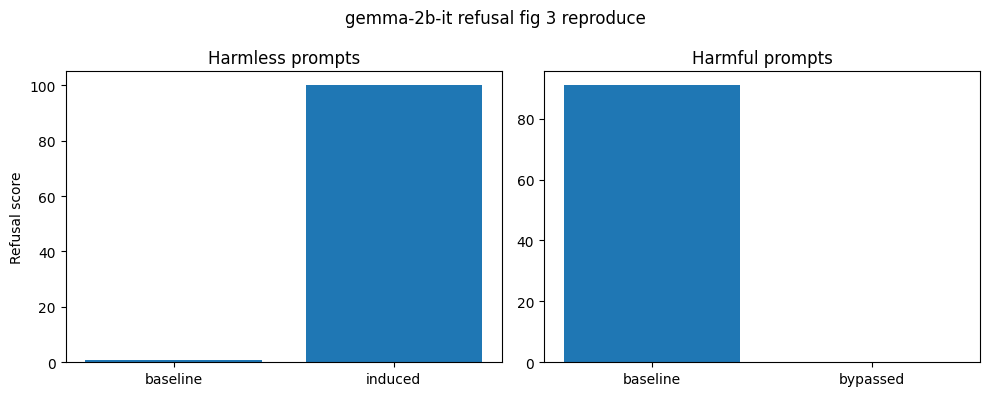

In [25]:
import matplotlib.pyplot as plt

induced_refusal_count = torch.tensor(induced_cases).sum().item()
baseline_induced_refusal_count = torch.tensor(baseline_induced_cases).sum().item()

bypassed_refusal_count = torch.tensor(bypassed_cases).sum().item()
baseline_bypassed_refusal_count = torch.tensor(baseline_bypassed_cases).sum().item()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plt.suptitle(f"{model_name.split("/")[1]} refusal fig 3 reproduce")

axes[0].bar(
    ["baseline", "induced"],
    [baseline_induced_refusal_count, induced_refusal_count],
)
axes[0].set_title("Harmless prompts")
axes[0].set_ylabel("Refusal score")

axes[1].bar(
    ["baseline", "bypassed"],
    [baseline_bypassed_refusal_count, bypassed_refusal_count],
)
axes[1].set_title("Harmful prompts")


plt.tight_layout()

BASE_DIR = Path("/content/drive/MyDrive/research/research-cycle1/throw-away-projects/refusal/")
SAVE_DIR = BASE_DIR / "results"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

save_path = SAVE_DIR / f"{model_name}refusal_fig3_reproduce.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()


Result Interpretation

Harmless prompts:
Adding the refusal direction induces refusal behavior.

Harmful prompts:
Ablating the refusal direction suppresses refusal behavior.

This supports the hypothesis that refusal is mediated by a single direction in the residual stream.